# 0318 Analysis (Experiment 3)

In [1]:
import json
import re
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from matplotlib_inline.backend_inline import set_matplotlib_formats

warnings.filterwarnings("ignore")

plt.style.use("default")
sns.set_palette("Set2")
plt.rcParams["figure.figsize"] = (12, 8)
plt.rcParams["font.size"] = 11
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", None)

set_matplotlib_formats("svg")
plt.rcParams["savefig.format"] = "svg"

## 1. Data Loading and Preprocessing

In [2]:
DATA_DIR = Path("../data/0318/data")
CSV_PATTERN = "user_*.csv"

INTERACTION_CONDITION_LABELS = {
    1: "Baseline",
    21: "Hover Show One",
    22: "Hover Show All",
    23: "Click Show One",
    24: "Click Show All",
    25: "Animation Show One",
    26: "Animation Show All",
}

TREATMENT_CONDITION_NUMBERS = [21, 22, 23, 24, 25, 26]
TREATMENT_TECHNIQUE_ORDER = [
    "Hover Show One",
    "Hover Show All",
    "Click Show One",
    "Click Show All",
    "Animation Show One",
    "Animation Show All",
]
INTERACTION_ORDER_WITH_BASELINE = ["Baseline"] + TREATMENT_TECHNIQUE_ORDER

VISUALIZATION_TECHNIQUE_LABELS = {
    "baseline": "Baseline",
    "confidence_interval": "PI",
    "ensemble_plot": "Ensemble",
    "combined_plot": "PI + Ensemble",
}
VISUALIZATION_ORDER = ["Baseline", "PI", "Ensemble", "PI + Ensemble"]

BASELINE_CONDITION_NUMBER = 1
NORMALIZED_FLAG_COLUMN = "_baseline_normalized"


def extract_condition_number(condition_id):
    if pd.isna(condition_id):
        return np.nan
    match = re.search(r"condition_(\d+)", str(condition_id))
    return int(match.group(1)) if match else np.nan


def map_interaction_group(condition_number):
    if pd.isna(condition_number):
        return "Other"
    return INTERACTION_CONDITION_LABELS.get(int(condition_number), "Other")


def map_visualization_group(row):
    condition_number = row.get("condition_number", np.nan)
    if pd.notna(condition_number) and int(condition_number) == BASELINE_CONDITION_NUMBER:
        return "Baseline"

    technique_raw = str(row.get("visualization_technique", "")).strip().lower()
    if technique_raw in VISUALIZATION_TECHNIQUE_LABELS:
        return VISUALIZATION_TECHNIQUE_LABELS[technique_raw]

    condition_id = str(row.get("condition_id", "")).strip().lower()
    if condition_id.endswith("_ci"):
        return "PI"
    if condition_id.endswith("_ep"):
        return "Ensemble"
    if condition_id.endswith("_ciep"):
        return "PI + Ensemble"

    condition_name = str(row.get("condition_name", "")).strip().lower()
    if "baseline" in condition_name:
        return "Baseline"
    if "combined" in condition_name:
        return "PI + Ensemble"
    if "ensemble" in condition_name:
        return "Ensemble"
    if "(ci)" in condition_name or "confidence" in condition_name:
        return "PI"

    return "Other"


def parse_response_json(value):
    if pd.isna(value):
        return {}
    if isinstance(value, dict):
        return value
    try:
        parsed = json.loads(value)
        return parsed if isinstance(parsed, dict) else {}
    except Exception:
        return {}


def expand_response_columns(data, response_col="response"):
    if response_col not in data.columns:
        return data.copy()

    parsed = data[response_col].apply(parse_response_json)
    expanded = pd.json_normalize(parsed)

    merged = data.reset_index(drop=True).copy()
    for col in expanded.columns:
        parsed_values = expanded[col]
        if col in merged.columns:
            merged[col] = merged[col].where(merged[col].notna(), parsed_values)
        else:
            merged[col] = parsed_values

    return merged


def _normalize_scores_by_participant_baseline(
    data,
    metric_columns,
    baseline_condition=BASELINE_CONDITION_NUMBER,
    drop_baseline=True,
):
    if data is None or data.empty:
        normalized = pd.DataFrame() if data is None else data.copy()
        if not normalized.empty:
            normalized[NORMALIZED_FLAG_COLUMN] = True
        return normalized

    required_cols = {"participant_id", "condition_number"}
    if not required_cols.issubset(data.columns):
        normalized = data.copy()
        normalized[NORMALIZED_FLAG_COLUMN] = False
        return normalized

    available_columns = [col for col in metric_columns if col in data.columns]
    if not available_columns:
        normalized = data.copy()
        normalized[NORMALIZED_FLAG_COLUMN] = False
        return normalized

    working = data.copy()
    working["condition_number"] = pd.to_numeric(working["condition_number"], errors="coerce")

    baseline_rows = working[working["condition_number"] == baseline_condition].copy()
    if baseline_rows.empty:
        normalized = working.copy()
        normalized[NORMALIZED_FLAG_COLUMN] = False
        return normalized

    baseline_lookup = (
        baseline_rows.groupby("participant_id", dropna=False)[available_columns]
        .mean()
        .rename(columns={col: f"{col}__baseline" for col in available_columns})
    )

    normalized = working.merge(
        baseline_lookup,
        left_on="participant_id",
        right_index=True,
        how="left",
    )

    for col in available_columns:
        baseline_col = f"{col}__baseline"
        normalized[col] = (
            pd.to_numeric(normalized[col], errors="coerce")
            - pd.to_numeric(normalized[baseline_col], errors="coerce")
        )

    baseline_columns = [f"{col}__baseline" for col in available_columns]
    normalized = normalized.drop(columns=[c for c in baseline_columns if c in normalized.columns])

    if drop_baseline:
        normalized = normalized[normalized["condition_number"] != baseline_condition].copy()

    normalized[NORMALIZED_FLAG_COLUMN] = True
    return normalized.reset_index(drop=True)


def load_participant_data(file_path):
    df = pd.read_csv(file_path)
    df["source_file"] = file_path.name

    if "participant_id" not in df.columns or df["participant_id"].isna().all():
        participant_id = file_path.stem.split("_")[1]
        df["participant_id"] = participant_id

    if "condition_id" not in df.columns:
        df["condition_id"] = np.nan
    if "condition_name" not in df.columns:
        df["condition_name"] = np.nan

    df["condition_number"] = df["condition_id"].apply(extract_condition_number)
    df["interaction_group"] = df["condition_number"].apply(map_interaction_group)
    df["visualization_group"] = df.apply(map_visualization_group, axis=1)

    return df


csv_files = sorted(DATA_DIR.glob(CSV_PATTERN))
if not csv_files:
    raise FileNotFoundError(f"No CSV files found in {DATA_DIR.resolve()} using pattern {CSV_PATTERN!r}")

all_data = [load_participant_data(file_path) for file_path in csv_files]
combined_data = pd.concat(all_data, ignore_index=True)

before_participants = combined_data["participant_id"].nunique(dropna=True)
combined_data = combined_data[combined_data["participant_id"].notna()].copy()
combined_data = combined_data[~combined_data["participant_id"].astype(str).str.lower().eq("test")].copy()
after_participants = combined_data["participant_id"].nunique(dropna=True)

print(f"Using data directory: {DATA_DIR.resolve()}")
print(f"Found {len(csv_files)} participant CSV files")
print(f"Combined dataset shape: {combined_data.shape}")
print(f"Participants: {before_participants} -> {after_participants}")
print("Sample files:")
for file_path in csv_files[:10]:
    print(f"  - {file_path.name}")
if len(csv_files) > 10:
    print(f"  ... and {len(csv_files) - 10} more")

Using data directory: /Users/songwen/Documents/Code Lab/Interact4Trust/Experiment3/data/0318/data
Found 27 participant CSV files
Combined dataset shape: (1188, 85)
Participants: 27 -> 27
Sample files:
  - user_512853846035319_2026-03-18T21-08-06-950.csv
  - user_525704878001810_2026-03-18T20-58-23-761.csv
  - user_5588532993045679_2026-03-18T22-31-34-317.csv
  - user_61113294966320303_2026-03-18T22-18-27-664.csv
  - user_65697815125708651_2026-03-18T21-32-22-200.csv
  - user_658283905003_2026-03-18T21-27-35-380.csv
  - user_6654853297436009095_2026-03-18T22-43-08-001.csv
  - user_671498899678533053_2026-03-18T21-39-21-829.csv
  - user_676996345572553_2026-03-18T21-00-53-445.csv
  - user_69391815754022_2026-03-18T20-53-50-629.csv
  ... and 17 more


In [3]:
print("Column names:")
print(combined_data.columns.tolist())

print()
print("Trial type counts:")
print(combined_data["trial_type"].value_counts(dropna=False).to_string())

condition_lookup = (
    combined_data[
        [
            "condition_number",
            "condition_id",
            "condition_name",
            "interaction_group",
            "visualization_group",
            "visualization_technique",
            "display_format",
        ]
    ]
    .dropna(subset=["condition_id"])
    .drop_duplicates()
    .sort_values(["condition_number", "condition_id"], na_position="last")
    .reset_index(drop=True)
)

print()
print("Conditions present in this dataset:")
display(condition_lookup)

Column names:
['city_a_color', 'city_a_estimate', 'city_a_label', 'city_b_color', 'city_b_estimate', 'city_b_label', 'click_events', 'comprehension_ease', 'condition', 'condition_id', 'condition_name', 'confidence_label', 'confidence_rating', 'data_trust', 'device_pixel_ratio', 'display_format', 'effective_screen_width_px', 'end_time', 'failed_audio', 'failed_images', 'failed_video', 'forecast_organization', 'hover_events', 'interaction_log', 'internal_node_id', 'participant_id', 'percent_score', 'phase', 'phase1_complete', 'phase2_complete', 'phase3_complete', 'phase4_complete', 'phase5_complete', 'phase6_complete', 'phase7_complete', 'phase_assignment_log', 'phase_completion', 'phase_dataset_assignment_log', 'phase_dataset_file', 'phase_execution_order', 'phase_key', 'phase_number', 'phase_slot', 'predictions_shown', 'probability_estimate', 'question_order', 'response', 'responses', 'round', 'rt', 'rt_total', 'screen_height', 'screen_width', 'skeptical_rating', 'slider_moved', 'start

,condition_number,condition_id,condition_name,interaction_group,visualization_group,visualization_technique,display_format
0,1.0,condition_1_baseline,Baseline,Baseline,Baseline,baseline,aggregation_only
1,21.0,condition_21_hover_show_one_ci,Hover Show One (CI),Hover Show One,PI,confidence_interval,hover_show_one
2,21.0,condition_21_hover_show_one_ciep,Hover Show One (Combined),Hover Show One,PI + Ensemble,combined_plot,hover_show_one
3,21.0,condition_21_hover_show_one_ep,Hover Show One (Ensemble),Hover Show One,Ensemble,ensemble_plot,hover_show_one
4,22.0,condition_22_hover_show_all_ci,Hover Show All (CI),Hover Show All,PI,confidence_interval,hover_show_all
5,22.0,condition_22_hover_show_all_ciep,Hover Show All (Combined),Hover Show All,PI + Ensemble,combined_plot,hover_show_all
6,22.0,condition_22_hover_show_all_ep,Hover Show All (Ensemble),Hover Show All,Ensemble,ensemble_plot,hover_show_all
7,23.0,condition_23_click_show_one_ci,Click Show One (CI),Click Show One,PI,confidence_interval,click_show_one
8,23.0,condition_23_click_show_one_ciep,Click Show One (Combined),Click Show One,PI + Ensemble,combined_plot,click_show_one
9,23.0,condition_23_click_show_one_ep,Click Show One (Ensemble),Click Show One,Ensemble,ensemble_plot,click_show_one


In [4]:
relevant_trial_types = [
    "prediction-task",
    "vis-literacy",
    "trust-survey",
    "interaction-feedback",
    "personality-survey",
    "survey-text",
    "survey-multi-choice",
]

relevant_trials = combined_data[combined_data["trial_type"].isin(relevant_trial_types)].copy()
relevant_trials["interaction_freq"] = np.log1p(
    relevant_trials["interaction_log"].fillna("").astype(str).str.len()
)

prediction_data = relevant_trials[relevant_trials["trial_type"] == "prediction-task"].copy()
baseline_prediction_data = prediction_data[prediction_data["condition_number"] == BASELINE_CONDITION_NUMBER].copy()
treatment_prediction_data = prediction_data[prediction_data["condition_number"].isin(TREATMENT_CONDITION_NUMBERS)].copy()

trust_survey_rows = relevant_trials[relevant_trials["trial_type"] == "trust-survey"].copy()
interaction_feedback_rows = relevant_trials[relevant_trials["trial_type"] == "interaction-feedback"].copy()

print(f"Relevant trial rows: {len(relevant_trials)}")
print(f"Prediction rows: {len(prediction_data)}")
print(f"Baseline prediction rows: {len(baseline_prediction_data)}")
print(f"Treatment prediction rows: {len(treatment_prediction_data)}")
print(f"Trust survey rows: {len(trust_survey_rows)}")
print(f"Interaction feedback rows: {len(interaction_feedback_rows)}")

coverage = (
    prediction_data.groupby("participant_id")["condition_number"]
    .apply(lambda s: sorted(int(v) for v in s.dropna().unique()))
    .value_counts()
)
print()
print("Per-participant condition coverage:")
print(coverage.to_string())

Relevant trial rows: 702
Prediction rows: 189
Baseline prediction rows: 27
Treatment prediction rows: 162
Trust survey rows: 189
Interaction feedback rows: 189

Per-participant condition coverage:
condition_number
[1, 21, 22, 23, 24, 25, 26]    27


## 2. Basic Statistics Tables by Condition

In [5]:
def summarize_prediction_metrics(data, label):
    if data.empty:
        print(f"No rows available for {label}")
        return pd.DataFrame()

    summary = (
        data.groupby(["condition_number", "interaction_group"], dropna=False)
        .agg(
            participants=("participant_id", "nunique"),
            trials=("participant_id", "size"),
            probability_mean=("probability_estimate", "mean"),
            probability_sd=("probability_estimate", "std"),
            confidence_mean=("confidence_rating", "mean"),
            confidence_sd=("confidence_rating", "std"),
            log_interaction_mean=("interaction_freq", "mean"),
            total_interactions_mean=("total_interactions", "mean"),
            time_on_viz_mean=("time_on_viz", "mean"),
        )
        .round(3)
        .reset_index()
        .sort_values("condition_number")
    )

    print(label)
    display(summary)
    return summary


baseline_summary = summarize_prediction_metrics(
    baseline_prediction_data,
    "Baseline prediction summary",
)

treatment_summary = summarize_prediction_metrics(
    treatment_prediction_data,
    "Treatment prediction summary (six interaction techniques)",
)

trust_columns_for_summary = [
    "skeptical_rating",
    "data_trust",
    "usability_difficulty",
    "comprehension_ease",
    "navigation_control",
    "content_control",
    "pace_control",
    "interface_exploration",
    "interface_responsiveness",
    "personal_conversation",
    "interface_interaction",
    "interface_sensitivity",
]
available_trust_columns = [c for c in trust_columns_for_summary if c in trust_survey_rows.columns]

if available_trust_columns:
    trust_basic_summary = (
        trust_survey_rows.groupby(["condition_number", "interaction_group"], dropna=False)[available_trust_columns]
        .mean()
        .round(3)
        .reset_index()
        .sort_values("condition_number")
    )
    print("Trust survey mean scores by condition")
    display(trust_basic_summary)
else:
    print("Trust summary skipped: trust survey columns not found.")

Baseline prediction summary


,condition_number,interaction_group,participants,trials,probability_mean,probability_sd,confidence_mean,confidence_sd,log_interaction_mean,total_interactions_mean,time_on_viz_mean
0,1.0,Baseline,27,27,54.222,20.102,4.667,1.414,11.639,489.148,62212.248


Treatment prediction summary (six interaction techniques)


,condition_number,interaction_group,participants,trials,probability_mean,probability_sd,confidence_mean,confidence_sd,log_interaction_mean,total_interactions_mean,time_on_viz_mean
0,21.0,Hover Show One,27,27,42.704,22.995,4.111,1.450,11.828,551.000,48199.833
1,22.0,Hover Show All,27,27,50.111,21.255,3.778,1.423,11.524,403.667,56840.470
2,23.0,Click Show One,27,27,44.704,20.084,4.148,1.537,12.042,629.444,64452.493
3,24.0,Click Show All,27,27,47.185,22.098,3.963,1.652,11.623,402.741,53501.693
4,25.0,Animation Show One,27,27,38.296,22.196,3.815,1.495,11.025,396.444,45764.593
5,26.0,Animation Show All,27,27,41.704,21.383,3.963,1.400,11.338,349.556,47449.752


Trust survey mean scores by condition


,condition_number,interaction_group,skeptical_rating,data_trust,usability_difficulty,comprehension_ease
0,1.0,Baseline,2.741,5.296,3.000,5.333
1,21.0,Hover Show One,2.704,5.111,3.704,5.074
2,22.0,Hover Show All,2.778,5.074,3.407,4.778
3,23.0,Click Show One,2.963,5.000,3.000,5.074
4,24.0,Click Show All,2.852,4.741,3.296,5.148
5,25.0,Animation Show One,3.148,4.889,3.926,4.778
6,26.0,Animation Show All,3.185,4.667,4.407,4.556


## 3. Phase 1 to Phase 2-7 Treatment Shift Visualizations

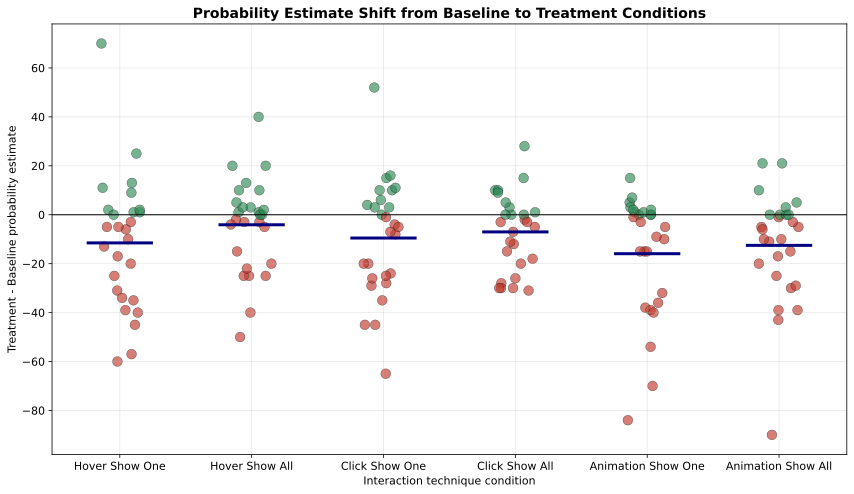

Shift summary for probability_estimate


,interaction_group,n,mean_shift,sd_shift,se_shift
0,Hover Show One,27,-11.519,27.273,5.249
1,Hover Show All,27,-4.111,19.124,3.680
2,Click Show One,27,-9.519,24.089,4.636
3,Click Show All,27,-7.037,15.713,3.024
4,Animation Show One,27,-15.926,24.898,4.792
5,Animation Show All,27,-12.519,22.764,4.381


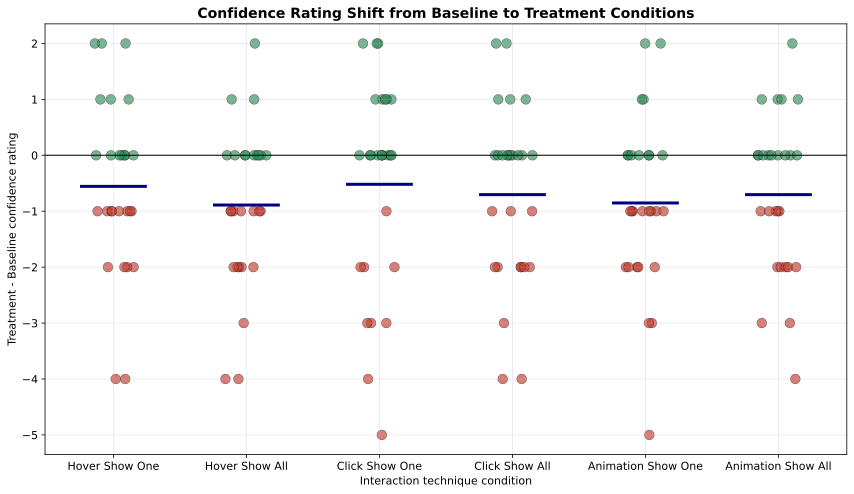

Shift summary for confidence_rating


,interaction_group,n,mean_shift,sd_shift,se_shift
0,Hover Show One,27,-0.556,1.553,0.299
1,Hover Show All,27,-0.889,1.423,0.274
2,Click Show One,27,-0.519,1.868,0.360
3,Click Show All,27,-0.704,1.589,0.306
4,Animation Show One,27,-0.852,1.537,0.296
5,Animation Show All,27,-0.704,1.436,0.276


In [6]:
def create_shift_plot(
    baseline_data,
    treatment_data,
    value_col,
    title,
    y_label,
    group_col="interaction_group",
    order=None,
):
    if order is None:
        order = TREATMENT_TECHNIQUE_ORDER

    baseline = (
        baseline_data.loc[baseline_data[value_col].notna(), ["participant_id", value_col]]
        .drop_duplicates(subset=["participant_id"], keep="last")
        .rename(columns={value_col: f"{value_col}_baseline"})
    )

    treatment = treatment_data[
        treatment_data[value_col].notna()
        & treatment_data[group_col].isin(order)
    ].copy()

    merged = treatment.merge(baseline, on="participant_id", how="inner")
    if merged.empty:
        print(f"No matched baseline/treatment rows found for {value_col}")
        return pd.DataFrame(), pd.DataFrame()

    merged["shift"] = merged[value_col] - merged[f"{value_col}_baseline"]

    summary = (
        merged.groupby(group_col, dropna=False)
        .agg(
            n=("participant_id", "size"),
            mean_shift=("shift", "mean"),
            sd_shift=("shift", "std"),
        )
        .reindex(order)
        .dropna(subset=["n"])
    )
    summary["se_shift"] = summary["sd_shift"] / np.sqrt(summary["n"].clip(lower=1))
    summary = summary.round(3).reset_index()

    fig, ax = plt.subplots(figsize=(12, 7))
    ax.axhline(0, color="black", linewidth=1.25, alpha=0.8)

    rng = np.random.default_rng(42)
    for idx, group_name in enumerate(order, start=1):
        group_rows = merged[merged[group_col] == group_name].copy()
        if group_rows.empty:
            continue
        jitter = rng.uniform(-0.16, 0.16, len(group_rows))
        colors = np.where(group_rows["shift"] >= 0, "#2E8B57", "#C0392B")

        ax.scatter(
            np.full(len(group_rows), idx) + jitter,
            group_rows["shift"],
            s=95,
            alpha=0.65,
            color=colors,
            edgecolors="black",
            linewidth=0.4,
        )

        mean_row = summary[summary[group_col] == group_name]
        if not mean_row.empty:
            mean_shift = mean_row["mean_shift"].iloc[0]
            ax.plot([idx - 0.24, idx + 0.24], [mean_shift, mean_shift], color="navy", linewidth=3)

    ax.set_xticks(range(1, len(order) + 1))
    ax.set_xticklabels(order)
    ax.set_xlabel("Interaction technique condition")
    ax.set_ylabel(y_label)
    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"Shift summary for {value_col}")
    display(summary)
    return merged, summary


probability_shift_data, probability_shift_summary = create_shift_plot(
    baseline_prediction_data,
    treatment_prediction_data,
    value_col="probability_estimate",
    title="Probability Estimate Shift from Baseline to Treatment Conditions",
    y_label="Treatment - Baseline probability estimate",
)

confidence_shift_data, confidence_shift_summary = create_shift_plot(
    baseline_prediction_data,
    treatment_prediction_data,
    value_col="confidence_rating",
    title="Confidence Rating Shift from Baseline to Treatment Conditions",
    y_label="Treatment - Baseline confidence rating",
)

## 4. Trust and Usability Measures

Trust survey expanded rows: 189
Baseline-normalized treatment trust rows: 162
Baseline-normalized treatment interaction rows: 162


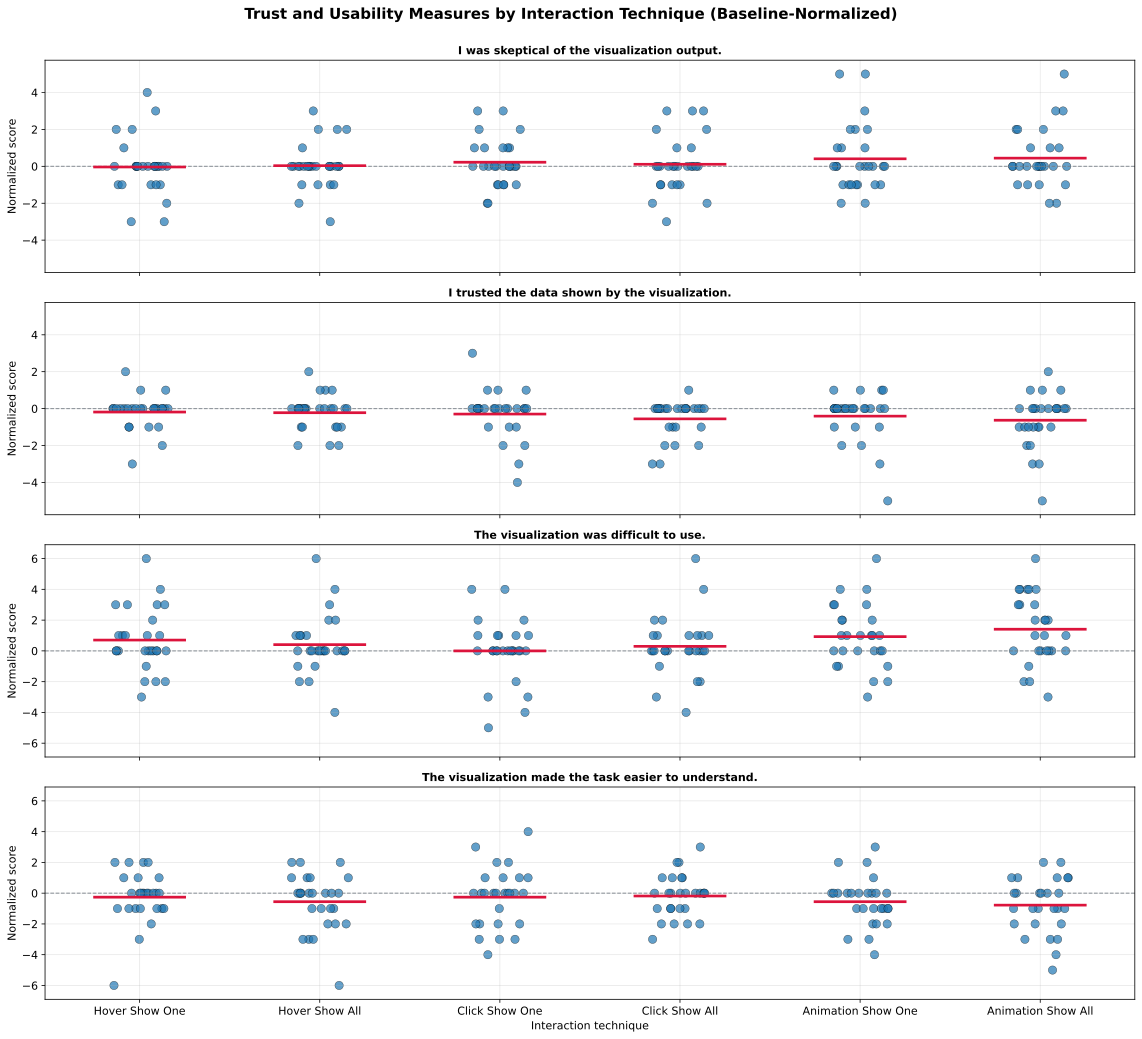

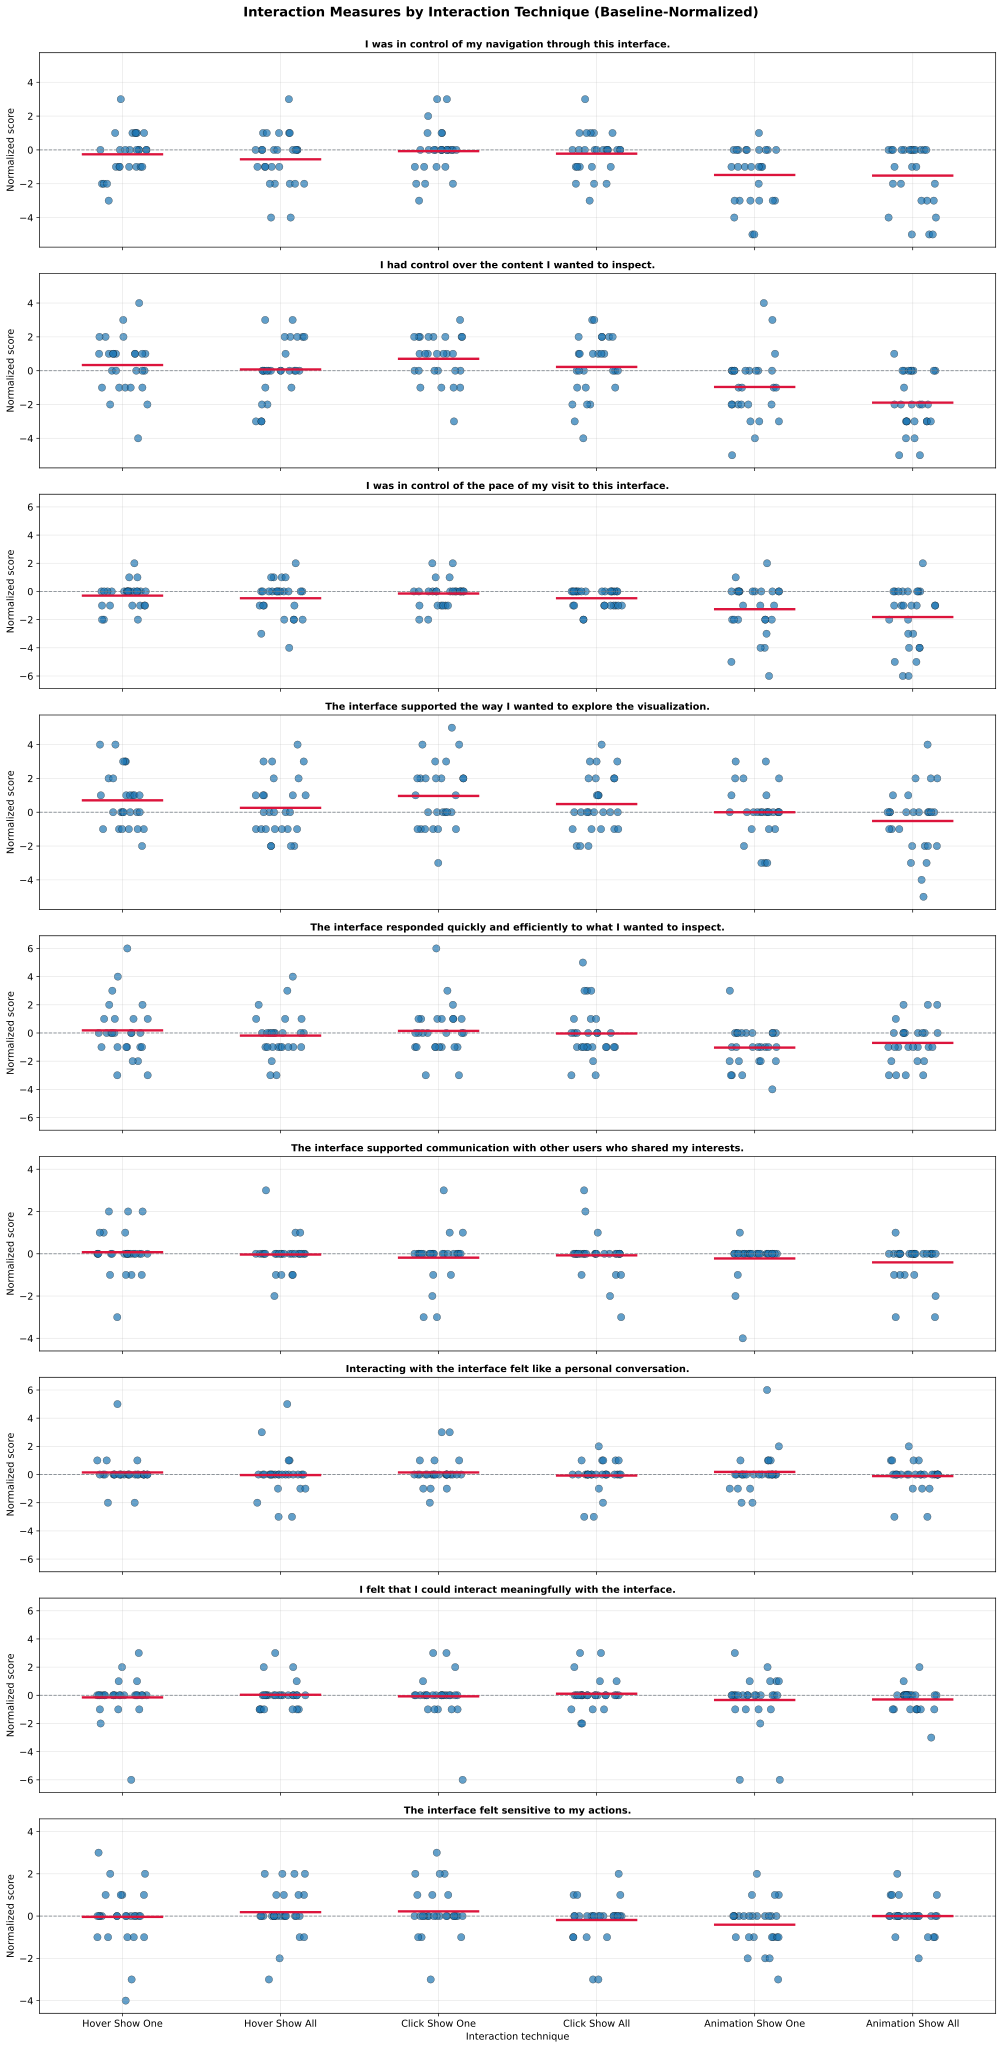

In [7]:
INTERACTION_QUESTION_KEYS = [
    "navigation_control",
    "content_control",
    "pace_control",
    "interface_exploration",
    "interface_responsiveness",
    "user_communication",
    "personal_conversation",
    "interface_interaction",
    "interface_sensitivity",
]

TRUST_QUESTION_KEYS = [
    "skeptical_rating",
    "data_trust",
    "usability_difficulty",
    "comprehension_ease",
]


trust_questions = [
    {"type": "skeptical_rating", "prompt": "I was skeptical of the visualization output."},
    {"type": "data_trust", "prompt": "I trusted the data shown by the visualization."},
    {"type": "usability_difficulty", "prompt": "The visualization was difficult to use."},
    {"type": "comprehension_ease", "prompt": "The visualization made the task easier to understand."},
]

interaction_questions = [
    {"type": "navigation_control", "prompt": "I was in control of my navigation through this interface."},
    {"type": "content_control", "prompt": "I had control over the content I wanted to inspect."},
    {"type": "pace_control", "prompt": "I was in control of the pace of my visit to this interface."},
    {"type": "interface_exploration", "prompt": "The interface supported the way I wanted to explore the visualization."},
    {"type": "interface_responsiveness", "prompt": "The interface responded quickly and efficiently to what I wanted to inspect."},
    {"type": "user_communication", "prompt": "The interface supported communication with other users who shared my interests."},
    {"type": "personal_conversation", "prompt": "Interacting with the interface felt like a personal conversation."},
    {"type": "interface_interaction", "prompt": "I felt that I could interact meaningfully with the interface."},
    {"type": "interface_sensitivity", "prompt": "The interface felt sensitive to my actions."},
]


def ensure_likert_columns(data, keys):
    if data.empty:
        return data.copy()

    working = data.copy()
    parsed = working["response"].apply(parse_response_json) if "response" in working.columns else pd.Series([{}] * len(working))

    for key in keys:
        existing = pd.to_numeric(working[key], errors="coerce") if key in working.columns else pd.Series(np.nan, index=working.index)

        if key not in working.columns or existing.notna().sum() == 0:
            extracted = pd.to_numeric(parsed.apply(lambda d: d.get(key, np.nan)), errors="coerce")
            valid = extracted.dropna()
            if not valid.empty and (valid >= 0).all() and (valid <= 6).all():
                extracted = extracted + 1
            working[key] = extracted
        else:
            working[key] = existing

    return working


trust_survey_expanded = ensure_likert_columns(
    trust_survey_rows,
    TRUST_QUESTION_KEYS + INTERACTION_QUESTION_KEYS,
)

analysis_metric_columns = [
    col for col in (TRUST_QUESTION_KEYS + INTERACTION_QUESTION_KEYS) if col in trust_survey_expanded.columns
]

analysis_trust_survey_expanded = _normalize_scores_by_participant_baseline(
    trust_survey_expanded,
    metric_columns=analysis_metric_columns,
    baseline_condition=BASELINE_CONDITION_NUMBER,
    drop_baseline=False,
)

analysis_treatment_survey = analysis_trust_survey_expanded[
    analysis_trust_survey_expanded["condition_number"].isin(TREATMENT_CONDITION_NUMBERS)
].copy()

analysis_trust_data = analysis_treatment_survey[
    analysis_treatment_survey[TRUST_QUESTION_KEYS].notna().any(axis=1)
].copy()
analysis_interaction_data = analysis_treatment_survey[
    analysis_treatment_survey[INTERACTION_QUESTION_KEYS].notna().any(axis=1)
].copy()

print(f"Trust survey expanded rows: {len(trust_survey_expanded)}")
print(f"Baseline-normalized treatment trust rows: {len(analysis_trust_data)}")
print(f"Baseline-normalized treatment interaction rows: {len(analysis_interaction_data)}")


def create_sectioned_survey_plots(data, questions, section_title, group_order=TREATMENT_TECHNIQUE_ORDER):
    if data is None or data.empty:
        print(f"No data available for {section_title}")
        return

    fig, axes = plt.subplots(len(questions), 1, figsize=(16, 3.6 * len(questions)), sharex=True)
    if len(questions) == 1:
        axes = [axes]

    position_map = {name: idx + 1 for idx, name in enumerate(group_order)}

    rng = np.random.default_rng(42)
    for ax, question in zip(axes, questions):
        key = question["type"]
        if key not in data.columns:
            ax.text(0.5, 0.5, "Column not found", transform=ax.transAxes, ha="center", va="center")
            ax.set_title(question["prompt"], fontsize=11, fontweight="bold")
            continue

        plot_rows = data[data[key].notna() & data["interaction_group"].isin(group_order)].copy()

        ax.axhline(0, color="#6c757d", linestyle="--", linewidth=1.0, alpha=0.8)

        for group_name in group_order:
            group_rows = plot_rows[plot_rows["interaction_group"] == group_name]
            if group_rows.empty:
                continue

            x_pos = position_map[group_name]
            jitter = rng.uniform(-0.16, 0.16, len(group_rows))
            ax.scatter(
                np.full(len(group_rows), x_pos) + jitter,
                pd.to_numeric(group_rows[key], errors="coerce"),
                alpha=0.7,
                s=70,
                edgecolors="black",
                linewidth=0.4,
                color="#1f77b4",
            )

            mean_value = pd.to_numeric(group_rows[key], errors="coerce").mean()
            ax.plot([x_pos - 0.25, x_pos + 0.25], [mean_value, mean_value], color="crimson", linewidth=2.7)

        max_abs = np.nanmax(np.abs(pd.to_numeric(plot_rows[key], errors="coerce"))) if not plot_rows.empty else 1
        y_limit = max(1.0, float(max_abs) * 1.15 if pd.notna(max_abs) else 1.0)

        ax.set_title(question["prompt"], fontsize=11, fontweight="bold")
        ax.set_ylabel("Normalized score")
        ax.set_ylim(-y_limit, y_limit)
        ax.grid(True, axis="y", alpha=0.3)

    axes[-1].set_xticks(list(position_map.values()))
    axes[-1].set_xticklabels(group_order)
    axes[-1].set_xlabel("Interaction technique")
    fig.suptitle(section_title, fontsize=15, fontweight="bold", y=1.0)
    plt.tight_layout()
    plt.show()


create_sectioned_survey_plots(
    analysis_trust_data,
    trust_questions,
    section_title="Trust and Usability Measures by Interaction Technique (Baseline-Normalized)",
)

create_sectioned_survey_plots(
    analysis_interaction_data,
    interaction_questions,
    section_title="Interaction Measures by Interaction Technique (Baseline-Normalized)",
)

## 5. Composite Scores, Interaction Frequency, and Feedback Page

Baseline-normalized composite trust by interaction technique


,interaction_group,n,mean_score,sd_score,se_score
0,Hover Show One,27,-0.278,0.926,0.178
1,Hover Show All,27,-0.306,0.864,0.166
2,Click Show One,27,-0.194,0.994,0.191
3,Click Show All,27,-0.287,0.898,0.173
4,Animation Show One,27,-0.574,1.168,0.225
5,Animation Show All,27,-0.815,1.222,0.235


Baseline-normalized composite interaction by interaction technique


,interaction_group,n,mean_score,sd_score,se_score
0,Hover Show One,27,0.078,0.694,0.134
1,Hover Show All,27,-0.082,0.699,0.135
2,Click Show One,27,0.189,0.779,0.150
3,Click Show All,27,-0.029,0.642,0.124
4,Animation Show One,27,-0.613,0.844,0.162
5,Animation Show All,27,-0.807,0.862,0.166


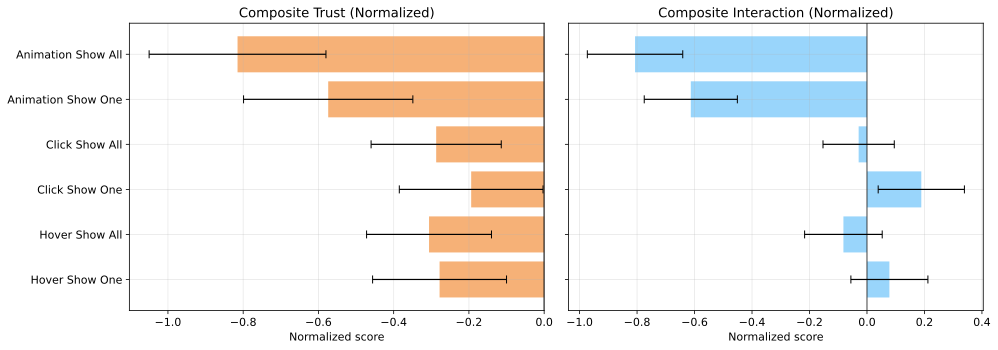

Baseline-normalized interaction frequency (log total interactions)


,interaction_group,n,mean_score,sd_score,se_score
0,Hover Show One,27,0.191,1.028,0.198
1,Hover Show All,27,-0.121,1.157,0.223
2,Click Show One,27,0.337,1.073,0.206
3,Click Show All,27,-0.056,1.214,0.234
4,Animation Show One,27,-0.430,1.211,0.233
5,Animation Show All,27,-0.298,0.949,0.183


encounter_bug response share by interaction technique


encounter_bug,No,Yes
interaction_group,,
Baseline,1.000,0.000
Hover Show One,0.963,0.037
Hover Show All,0.963,0.037
Click Show One,1.000,0.000
Click Show All,0.926,0.074
Animation Show One,1.000,0.000
Animation Show All,0.926,0.074


annoying_design response share by interaction technique


annoying_design,No,Yes
interaction_group,,
Baseline,1.000,0.000
Hover Show One,0.963,0.037
Hover Show All,0.889,0.111
Click Show One,1.000,0.000
Click Show All,0.889,0.111
Animation Show One,0.815,0.185
Animation Show All,0.778,0.222


In [8]:
def compute_composite_scores(data):
    if data is None or data.empty:
        return pd.DataFrame()

    working = data.copy()

    for col in TRUST_QUESTION_KEYS + INTERACTION_QUESTION_KEYS:
        if col in working.columns:
            working[col] = pd.to_numeric(working[col], errors="coerce")

    if {"skeptical_rating", "data_trust", "usability_difficulty", "comprehension_ease"}.issubset(working.columns):
        working["skeptical_rating_rev"] = 8 - working["skeptical_rating"]
        working["usability_difficulty_rev"] = 8 - working["usability_difficulty"]
        working["composite_trust_score"] = working[
            ["skeptical_rating_rev", "data_trust", "usability_difficulty_rev", "comprehension_ease"]
        ].mean(axis=1, skipna=True)

    interaction_available = [k for k in INTERACTION_QUESTION_KEYS if k in working.columns]
    if interaction_available:
        working["composite_interaction_score"] = working[interaction_available].mean(axis=1, skipna=True)

    return working


def summarize_metric_by_group(data, value_col, group_col="interaction_group", order=None):
    if order is None:
        order = TREATMENT_TECHNIQUE_ORDER

    if data.empty or value_col not in data.columns:
        return pd.DataFrame(columns=[group_col, "n", "mean_score", "sd_score", "se_score"])

    summary = (
        data[data[group_col].isin(order) & data[value_col].notna()]
        .groupby(group_col, as_index=False)[value_col]
        .agg(n="count", mean_score="mean", sd_score="std")
    )
    summary["se_score"] = summary["sd_score"] / np.sqrt(summary["n"].clip(lower=1))

    summary[group_col] = pd.Categorical(summary[group_col], categories=order, ordered=True)
    summary = summary.sort_values(group_col).reset_index(drop=True)
    return summary.round(3)


def plot_summary_barh(ax, summary, group_col, x_col, se_col, title, color):
    if summary.empty:
        ax.set_title(title)
        ax.text(0.5, 0.5, "No data", transform=ax.transAxes, ha="center", va="center")
        return

    y = np.arange(len(summary))
    ax.barh(y, summary[x_col], color=color, alpha=0.85)

    if se_col in summary.columns:
        ax.errorbar(
            summary[x_col],
            y,
            xerr=summary[se_col],
            fmt="none",
            ecolor="black",
            capsize=4,
            linewidth=1.2,
        )

    ax.set_yticks(y)
    ax.set_yticklabels(summary[group_col].astype(str).tolist())
    ax.axvline(0, color="black", linewidth=1.0, alpha=0.7)
    ax.set_xlabel("Normalized score")
    ax.set_title(title)
    ax.grid(True, axis="x", alpha=0.3)


composite_source = compute_composite_scores(trust_survey_expanded)
composite_normalized = _normalize_scores_by_participant_baseline(
    composite_source,
    metric_columns=["composite_trust_score", "composite_interaction_score"],
    baseline_condition=BASELINE_CONDITION_NUMBER,
    drop_baseline=False,
)

composite_treatment = composite_normalized[
    composite_normalized["condition_number"].isin(TREATMENT_CONDITION_NUMBERS)
].copy()

composite_trust_summary = summarize_metric_by_group(
    composite_treatment,
    value_col="composite_trust_score",
    group_col="interaction_group",
)

composite_interaction_summary = summarize_metric_by_group(
    composite_treatment,
    value_col="composite_interaction_score",
    group_col="interaction_group",
)

print("Baseline-normalized composite trust by interaction technique")
display(composite_trust_summary)

print("Baseline-normalized composite interaction by interaction technique")
display(composite_interaction_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
plot_summary_barh(
    axes[0],
    composite_trust_summary,
    group_col="interaction_group",
    x_col="mean_score",
    se_col="se_score",
    title="Composite Trust (Normalized)",
    color="#F4A460",
)
plot_summary_barh(
    axes[1],
    composite_interaction_summary,
    group_col="interaction_group",
    x_col="mean_score",
    se_col="se_score",
    title="Composite Interaction (Normalized)",
    color="#87CEFA",
)
plt.tight_layout()
plt.show()


prediction_behavior = prediction_data.copy()
prediction_behavior["log_total_interactions"] = np.log1p(
    pd.to_numeric(prediction_behavior["total_interactions"], errors="coerce")
)
prediction_behavior["time_on_viz"] = pd.to_numeric(prediction_behavior["time_on_viz"], errors="coerce")
prediction_behavior["confidence_rating"] = pd.to_numeric(prediction_behavior["confidence_rating"], errors="coerce")

prediction_behavior_normalized = _normalize_scores_by_participant_baseline(
    prediction_behavior,
    metric_columns=["log_total_interactions", "time_on_viz", "confidence_rating"],
    baseline_condition=BASELINE_CONDITION_NUMBER,
    drop_baseline=False,
)

prediction_behavior_treatment = prediction_behavior_normalized[
    prediction_behavior_normalized["condition_number"].isin(TREATMENT_CONDITION_NUMBERS)
].copy()

interaction_freq_summary = summarize_metric_by_group(
    prediction_behavior_treatment,
    value_col="log_total_interactions",
    group_col="interaction_group",
)

print("Baseline-normalized interaction frequency (log total interactions)")
display(interaction_freq_summary)


feedback_expanded = expand_response_columns(interaction_feedback_rows)
feedback_expanded["condition_number"] = feedback_expanded["condition_id"].apply(extract_condition_number)
feedback_expanded["interaction_group"] = feedback_expanded["condition_number"].apply(map_interaction_group)

feedback_cols = ["encounter_bug", "annoying_design"]
for col in feedback_cols:
    if col not in feedback_expanded.columns:
        continue

    print(f"{col} response share by interaction technique")
    table = pd.crosstab(
        feedback_expanded["interaction_group"],
        feedback_expanded[col],
        normalize="index",
    ).reindex(INTERACTION_ORDER_WITH_BASELINE)
    display(table.round(3))

## 5.1 Factor Analysis of Trust vs Interaction Questions


=== Trust / Usability Block ===
Rows used: 162
Variables tested: 4
Kaiser eigenvalues > 1: 2, using 2 factor(s)


,Factor 1,Factor 2,max_abs_loading
usability_difficulty,1.059149,-1.339230,1.339230
skeptical_rating,1.062084,0.513828,1.062084
data_trust,-0.733263,-0.447821,0.733263
comprehension_ease,-0.474274,0.395586,0.474274


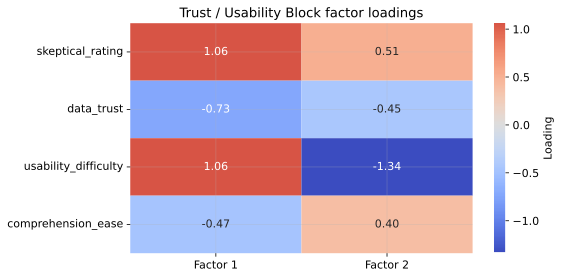


=== Interaction Block ===
Rows used: 162
Variables tested: 9
Kaiser eigenvalues > 1: 3, using 3 factor(s)


,Factor 1,Factor 2,Factor 3,max_abs_loading
content_control,-1.355901,0.169801,-0.125454,1.355901
navigation_control,-1.271101,0.012102,-0.156689,1.271101
interface_exploration,-1.203419,0.828615,0.367654,1.203419
pace_control,-1.164179,-0.650822,-0.064953,1.164179
personal_conversation,-0.122174,-0.219964,0.826389,0.826389
interface_responsiveness,-0.725886,0.520405,0.156196,0.725886
interface_interaction,-0.303230,0.372410,-0.617291,0.617291
interface_sensitivity,-0.368273,0.171825,-0.146270,0.368273
user_communication,-0.086108,0.093756,0.191902,0.191902


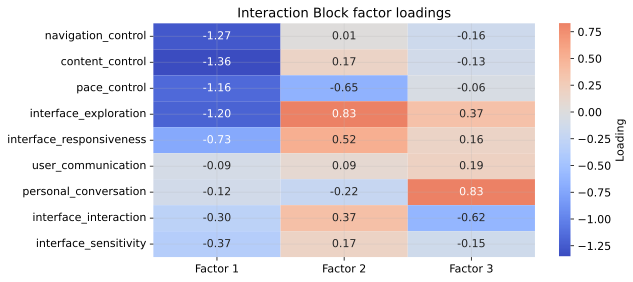

In [9]:
# Factor analysis on survey dimensions (trust vs interaction), performed separately.

from sklearn.decomposition import FactorAnalysis


def run_factor_analysis(data, question_keys, section_label):
    if data is None or data.empty:
        print(f"[skip] {section_label}: no rows available.")
        return {}

    available_keys = [k for k in question_keys if k in data.columns]
    if len(available_keys) < 2:
        print(f"[skip] {section_label}: fewer than 2 usable columns.")
        return {}

    analysis_rows = data[available_keys].apply(pd.to_numeric, errors="coerce").dropna()

    if analysis_rows.shape[0] < 10 or analysis_rows.shape[1] < 2:
        print(
            f"[skip] {section_label}: insufficient complete rows/columns "
            f"(n={analysis_rows.shape[0]}, p={analysis_rows.shape[1]})."
        )
        return {}

    constant_columns = [col for col in analysis_rows.columns if analysis_rows[col].nunique(dropna=True) <= 1]
    if constant_columns:
        analysis_rows = analysis_rows.drop(columns=constant_columns)

    if analysis_rows.shape[1] < 2:
        print(f"[skip] {section_label}: too few non-constant columns.")
        return {}

    corr = analysis_rows.corr().to_numpy()
    eigvals = np.sort(np.real(np.linalg.eigvalsh(corr)))[::-1]

    n_factors = int((eigvals > 1.0).sum())
    n_factors = max(1, min(n_factors, analysis_rows.shape[1], analysis_rows.shape[0] - 1, 3))

    fa = FactorAnalysis(n_components=n_factors, random_state=42)
    factor_scores = fa.fit_transform(analysis_rows)

    loading_matrix = pd.DataFrame(
        fa.components_.T,
        index=analysis_rows.columns,
        columns=[f"Factor {i + 1}" for i in range(n_factors)],
    )
    loading_matrix["max_abs_loading"] = loading_matrix.abs().max(axis=1)

    print()
    print(f"=== {section_label} ===")
    print(f"Rows used: {len(analysis_rows)}")
    print(f"Variables tested: {analysis_rows.shape[1]}")
    print(f"Kaiser eigenvalues > 1: {int((eigvals > 1).sum())}, using {n_factors} factor(s)")

    display(loading_matrix.sort_values("max_abs_loading", ascending=False))

    plt.figure(figsize=(max(8, 2 * n_factors + 3), max(4, len(analysis_rows.columns) * 0.45)))
    sns.heatmap(
        loading_matrix[[f"Factor {i + 1}" for i in range(n_factors)]],
        annot=True,
        cmap="coolwarm",
        center=0,
        fmt=".2f",
        cbar_kws={"label": "Loading"},
    )
    plt.title(f"{section_label} factor loadings")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    return {
        "n_factors": n_factors,
        "loadings": loading_matrix,
        "scores": pd.DataFrame(factor_scores, columns=[f"Factor {i + 1}" for i in range(n_factors)]),
    }


trust_factor_results = run_factor_analysis(
    analysis_treatment_survey,
    TRUST_QUESTION_KEYS,
    "Trust / Usability Block",
)

interaction_factor_results = run_factor_analysis(
    analysis_treatment_survey,
    INTERACTION_QUESTION_KEYS,
    "Interaction Block",
)

## 5.2 Factor-Aligned Comparison: Trust, Control, Interface

Trust-aligned by interaction technique


,interaction_group,n,mean_score,sd_score,se_score
0,Hover Show One,27,-0.278,0.926,0.178
1,Hover Show All,27,-0.306,0.864,0.166
2,Click Show One,27,-0.194,0.994,0.191
3,Click Show All,27,-0.287,0.898,0.173
4,Animation Show One,27,-0.574,1.168,0.225
5,Animation Show All,27,-0.815,1.222,0.235


Control by interaction technique


,interaction_group,n,mean_score,sd_score,se_score
0,Hover Show One,27,0.062,0.785,0.151
1,Hover Show All,27,-0.062,0.785,0.151
2,Click Show One,27,0.074,0.818,0.157
3,Click Show All,27,0.000,0.801,0.154
4,Animation Show One,27,-0.395,0.817,0.157
5,Animation Show All,27,-0.370,0.781,0.150


Interface by interaction technique


,interaction_group,n,mean_score,sd_score,se_score
0,Hover Show One,27,0.086,0.806,0.155
1,Hover Show All,27,-0.093,0.928,0.179
2,Click Show One,27,0.247,0.863,0.166
3,Click Show All,27,-0.043,0.718,0.138
4,Animation Show One,27,-0.722,1.015,0.195
5,Animation Show All,27,-1.025,1.078,0.207


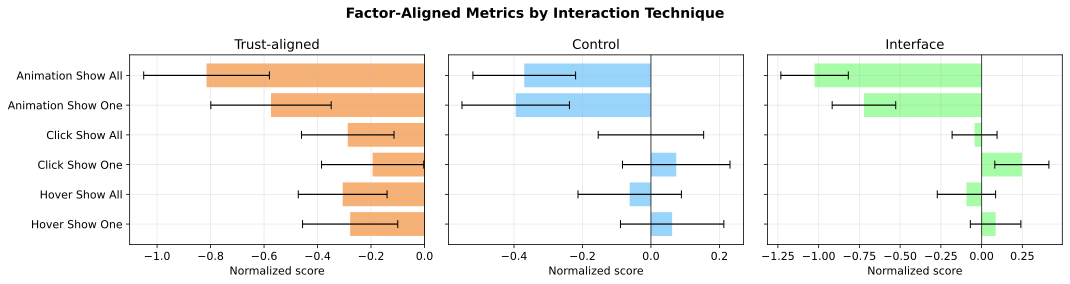

In [10]:
CONTROL_ITEM_KEYS = [
    "interface_interaction",
    "personal_conversation",
    "interface_responsiveness",
]

INTERFACE_ITEM_KEYS = [
    "interface_exploration",
    "navigation_control",
    "content_control",
    "pace_control",
    "interface_sensitivity",
    "user_communication",
]


def build_factor_aligned_scores(data):
    if data is None or data.empty:
        return pd.DataFrame()

    df = data.copy()
    keys_to_numeric = list(set(TRUST_QUESTION_KEYS + CONTROL_ITEM_KEYS + INTERFACE_ITEM_KEYS))
    for key in keys_to_numeric:
        if key in df.columns:
            df[key] = pd.to_numeric(df[key], errors="coerce")

    trust_components = []
    if "skeptical_rating" in df.columns:
        trust_components.append((-df["skeptical_rating"]).rename("skeptical_rating_aligned"))
    if "data_trust" in df.columns:
        trust_components.append(df["data_trust"])
    if "usability_difficulty" in df.columns:
        trust_components.append((-df["usability_difficulty"]).rename("usability_difficulty_aligned"))
    if "comprehension_ease" in df.columns:
        trust_components.append(df["comprehension_ease"])

    if trust_components:
        df["trust_aligned_score"] = pd.concat(trust_components, axis=1).mean(axis=1, skipna=True)

    control_keys = [k for k in CONTROL_ITEM_KEYS if k in df.columns]
    if control_keys:
        df["control_score"] = df[control_keys].mean(axis=1, skipna=True)

    interface_keys = [k for k in INTERFACE_ITEM_KEYS if k in df.columns]
    if interface_keys:
        df["interface_score"] = df[interface_keys].mean(axis=1, skipna=True)

    return df


def summarize_metric(data, value_col, group_col, order):
    if data.empty or value_col not in data.columns:
        return pd.DataFrame(columns=[group_col, "n", "mean_score", "sd_score", "se_score"])

    summary = (
        data[data[group_col].isin(order) & data[value_col].notna()]
        .groupby(group_col, as_index=False)[value_col]
        .agg(n="count", mean_score="mean", sd_score="std")
    )
    summary["se_score"] = summary["sd_score"] / np.sqrt(summary["n"].clip(lower=1))
    summary[group_col] = pd.Categorical(summary[group_col], categories=order, ordered=True)
    summary = summary.sort_values(group_col).reset_index(drop=True)
    return summary.round(3)


def plot_metric_panel(metric_summaries, group_col, title_prefix):
    fig, axes = plt.subplots(1, len(metric_summaries), figsize=(5 * len(metric_summaries), 4), sharey=True)
    if len(metric_summaries) == 1:
        axes = [axes]

    for ax, (metric_label, summary, color) in zip(axes, metric_summaries):
        if summary.empty:
            ax.set_title(f"{metric_label} (no data)")
            ax.text(0.5, 0.5, "No data", transform=ax.transAxes, ha="center", va="center")
            continue

        y = np.arange(len(summary))
        ax.barh(y, summary["mean_score"], color=color, alpha=0.85)
        ax.errorbar(
            summary["mean_score"],
            y,
            xerr=summary["se_score"],
            fmt="none",
            ecolor="black",
            capsize=4,
            linewidth=1.2,
        )
        ax.set_yticks(y)
        ax.set_yticklabels(summary[group_col].astype(str).tolist())
        ax.axvline(0, color="black", linewidth=1.0, alpha=0.7)
        ax.set_xlabel("Normalized score")
        ax.set_title(metric_label)
        ax.grid(True, axis="x", alpha=0.3)

    fig.suptitle(title_prefix, fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()


factor_aligned_data = build_factor_aligned_scores(analysis_treatment_survey)

interaction_metric_specs = [
    ("Trust-aligned", "trust_aligned_score", "#F4A460"),
    ("Control", "control_score", "#87CEFA"),
    ("Interface", "interface_score", "#98FB98"),
]

interaction_metric_summaries = []
for label, metric_col, color in interaction_metric_specs:
    summary = summarize_metric(
        factor_aligned_data,
        value_col=metric_col,
        group_col="interaction_group",
        order=TREATMENT_TECHNIQUE_ORDER,
    )
    print(f"{label} by interaction technique")
    display(summary)
    interaction_metric_summaries.append((label, summary, color))

plot_metric_panel(
    interaction_metric_summaries,
    group_col="interaction_group",
    title_prefix="Factor-Aligned Metrics by Interaction Technique",
)

## 6. Cross-Visualization Type Analysis (Baseline, PI, Ensemble, PI + Ensemble)

Composite trust by visualization type (baseline-normalized)


,visualization_group,n,mean_score,sd_score,se_score
0,Baseline,27,0.000,0.000,0.000
1,PI,60,-0.033,0.958,0.124
2,Ensemble,48,-0.786,1.167,0.168
3,PI + Ensemble,54,-0.491,0.828,0.113


Composite interaction by visualization type (baseline-normalized)


,visualization_group,n,mean_score,sd_score,se_score
0,Baseline,27,0.000,0.000,0.000
1,PI,60,-0.339,0.886,0.114
2,Ensemble,48,-0.120,0.714,0.103
3,PI + Ensemble,54,-0.148,0.863,0.117


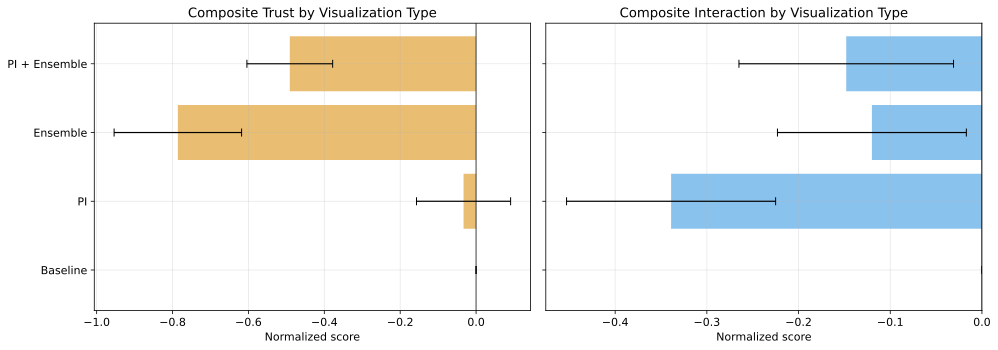

Confidence shift by visualization type


,visualization_group,n,mean_score,sd_score,se_score
0,Baseline,27,0.000,0.000,0.000
1,PI,60,-0.117,1.451,0.187
2,Ensemble,48,-1.250,1.657,0.239
3,PI + Ensemble,54,-0.870,1.374,0.187


In [11]:
VIS_GROUP_ORDER_NO_BASELINE = ["PI", "Ensemble", "PI + Ensemble"]
VIS_GROUP_ORDER_WITH_BASELINE = ["Baseline", "PI", "Ensemble", "PI + Ensemble"]


def summarize_with_optional_baseline_zero(data, value_col, group_col, order_no_baseline, baseline_n):
    summary = summarize_metric_by_group(
        data,
        value_col=value_col,
        group_col=group_col,
        order=order_no_baseline,
    )

    baseline_row = pd.DataFrame(
        [{group_col: "Baseline", "n": baseline_n, "mean_score": 0.0, "sd_score": 0.0, "se_score": 0.0}]
    )

    full = pd.concat([baseline_row, summary], ignore_index=True)
    full[group_col] = pd.Categorical(full[group_col], categories=VIS_GROUP_ORDER_WITH_BASELINE, ordered=True)
    full = full.sort_values(group_col).reset_index(drop=True)
    return full


baseline_n = combined_data.loc[combined_data["condition_number"] == BASELINE_CONDITION_NUMBER, "participant_id"].nunique()

visualization_trust_summary = summarize_with_optional_baseline_zero(
    composite_treatment,
    value_col="composite_trust_score",
    group_col="visualization_group",
    order_no_baseline=VIS_GROUP_ORDER_NO_BASELINE,
    baseline_n=baseline_n,
)

visualization_interaction_summary = summarize_with_optional_baseline_zero(
    composite_treatment,
    value_col="composite_interaction_score",
    group_col="visualization_group",
    order_no_baseline=VIS_GROUP_ORDER_NO_BASELINE,
    baseline_n=baseline_n,
)

print("Composite trust by visualization type (baseline-normalized)")
display(visualization_trust_summary)

print("Composite interaction by visualization type (baseline-normalized)")
display(visualization_interaction_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
plot_summary_barh(
    axes[0],
    visualization_trust_summary,
    group_col="visualization_group",
    x_col="mean_score",
    se_col="se_score",
    title="Composite Trust by Visualization Type",
    color="#E6B35A",
)
plot_summary_barh(
    axes[1],
    visualization_interaction_summary,
    group_col="visualization_group",
    x_col="mean_score",
    se_col="se_score",
    title="Composite Interaction by Visualization Type",
    color="#76B7EB",
)
plt.tight_layout()
plt.show()

if not confidence_shift_data.empty and "visualization_group" in confidence_shift_data.columns:
    confidence_by_vis = summarize_metric_by_group(
        confidence_shift_data.rename(columns={"shift": "confidence_shift"}),
        value_col="confidence_shift",
        group_col="visualization_group",
        order=VIS_GROUP_ORDER_NO_BASELINE,
    )
    baseline_row = pd.DataFrame(
        [{"visualization_group": "Baseline", "n": baseline_n, "mean_score": 0.0, "sd_score": 0.0, "se_score": 0.0}]
    )
    confidence_by_vis = pd.concat([baseline_row, confidence_by_vis], ignore_index=True)
    confidence_by_vis["visualization_group"] = pd.Categorical(
        confidence_by_vis["visualization_group"],
        categories=VIS_GROUP_ORDER_WITH_BASELINE,
        ordered=True,
    )
    confidence_by_vis = confidence_by_vis.sort_values("visualization_group").reset_index(drop=True)

    print("Confidence shift by visualization type")
    display(confidence_by_vis)

## 7. Cross-Interaction Technique Analysis (Hover, Click, Animation)

Normalized composite trust by interaction technique


,interaction_group,n,mean_score,sd_score,se_score
0,Hover Show One,27,-0.278,0.926,0.178
1,Hover Show All,27,-0.306,0.864,0.166
2,Click Show One,27,-0.194,0.994,0.191
3,Click Show All,27,-0.287,0.898,0.173
4,Animation Show One,27,-0.574,1.168,0.225
5,Animation Show All,27,-0.815,1.222,0.235


Normalized composite interaction by interaction technique


,interaction_group,n,mean_score,sd_score,se_score
0,Hover Show One,27,0.078,0.694,0.134
1,Hover Show All,27,-0.082,0.699,0.135
2,Click Show One,27,0.189,0.779,0.150
3,Click Show All,27,-0.029,0.642,0.124
4,Animation Show One,27,-0.613,0.844,0.162
5,Animation Show All,27,-0.807,0.862,0.166


Confidence shift by interaction technique


,interaction_group,n,mean_score,sd_score,se_score
0,Hover Show One,27,-0.556,1.553,0.299
1,Hover Show All,27,-0.889,1.423,0.274
2,Click Show One,27,-0.519,1.868,0.360
3,Click Show All,27,-0.704,1.589,0.306
4,Animation Show One,27,-0.852,1.537,0.296
5,Animation Show All,27,-0.704,1.436,0.276


,interaction_group,trust_mean,trust_se,interaction_mean,interaction_se
0,Hover Show One,-0.278,0.178,0.078,0.134
1,Hover Show All,-0.306,0.166,-0.082,0.135
2,Click Show One,-0.194,0.191,0.189,0.150
3,Click Show All,-0.287,0.173,-0.029,0.124
4,Animation Show One,-0.574,0.225,-0.613,0.162
5,Animation Show All,-0.815,0.235,-0.807,0.166


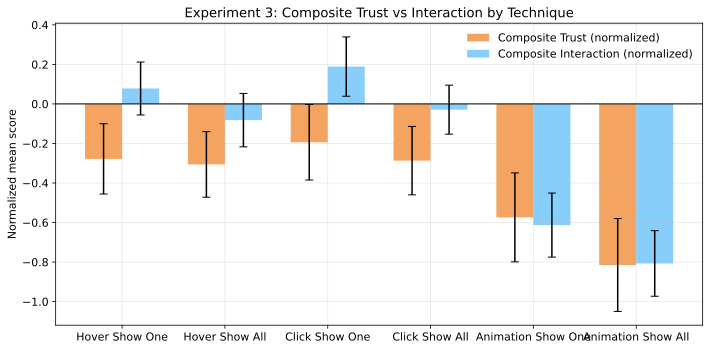

In [12]:
# In Experiment 3, this section is adapted to six interaction techniques:
# Hover Show One, Hover Show All, Click Show One, Click Show All, Animation Show One, Animation Show All.

interaction_composite_trust_summary = summarize_metric_by_group(
    composite_treatment,
    value_col="composite_trust_score",
    group_col="interaction_group",
    order=TREATMENT_TECHNIQUE_ORDER,
)

interaction_composite_interaction_summary = summarize_metric_by_group(
    composite_treatment,
    value_col="composite_interaction_score",
    group_col="interaction_group",
    order=TREATMENT_TECHNIQUE_ORDER,
)

interaction_confidence_shift_summary = summarize_metric_by_group(
    confidence_shift_data.rename(columns={"shift": "confidence_shift"}) if not confidence_shift_data.empty else pd.DataFrame(),
    value_col="confidence_shift",
    group_col="interaction_group",
    order=TREATMENT_TECHNIQUE_ORDER,
)

print("Normalized composite trust by interaction technique")
display(interaction_composite_trust_summary)

print("Normalized composite interaction by interaction technique")
display(interaction_composite_interaction_summary)

print("Confidence shift by interaction technique")
display(interaction_confidence_shift_summary)

comparison = (
    interaction_composite_trust_summary[["interaction_group", "mean_score", "se_score"]]
    .rename(columns={"mean_score": "trust_mean", "se_score": "trust_se"})
    .merge(
        interaction_composite_interaction_summary[["interaction_group", "mean_score", "se_score"]]
        .rename(columns={"mean_score": "interaction_mean", "se_score": "interaction_se"}),
        on="interaction_group",
        how="outer",
    )
)
comparison["interaction_group"] = pd.Categorical(
    comparison["interaction_group"],
    categories=TREATMENT_TECHNIQUE_ORDER,
    ordered=True,
)
comparison = comparison.sort_values("interaction_group").reset_index(drop=True)

display(comparison)

x = np.arange(len(comparison))
width = 0.36

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(
    x - width / 2,
    comparison["trust_mean"],
    width,
    yerr=comparison["trust_se"],
    capsize=4,
    label="Composite Trust (normalized)",
    color="#F4A460",
)
ax.bar(
    x + width / 2,
    comparison["interaction_mean"],
    width,
    yerr=comparison["interaction_se"],
    capsize=4,
    label="Composite Interaction (normalized)",
    color="#87CEFA",
)

ax.axhline(0, color="black", linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(comparison["interaction_group"].astype(str).tolist())
ax.set_ylabel("Normalized mean score")
ax.set_title("Experiment 3: Composite Trust vs Interaction by Technique")
ax.legend(frameon=False)
ax.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

Condition-level normalized composite means


,condition_number,interaction_group,trust_mean,trust_sd,interaction_mean,interaction_sd,n,trust_se,interaction_se
0,21.0,Hover Show One,-0.278,0.926,0.078,0.694,27,0.178,0.134
1,22.0,Hover Show All,-0.306,0.864,-0.082,0.699,27,0.166,0.135
2,23.0,Click Show One,-0.194,0.994,0.189,0.779,27,0.191,0.150
3,24.0,Click Show All,-0.287,0.898,-0.029,0.642,27,0.173,0.124
4,25.0,Animation Show One,-0.574,1.168,-0.613,0.844,27,0.225,0.162
5,26.0,Animation Show All,-0.815,1.222,-0.807,0.862,27,0.235,0.166


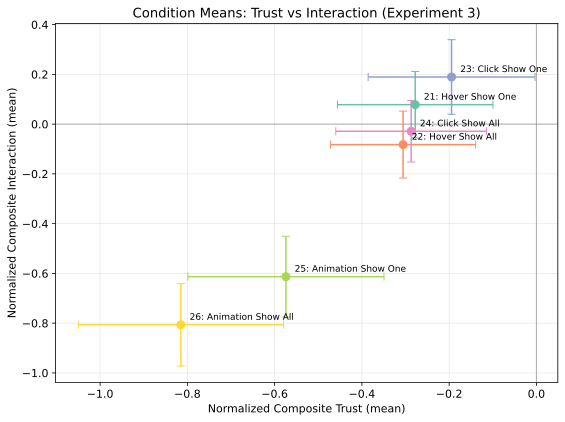

In [13]:
# 8. Combined condition means for trust vs interaction

condition_level_summary = (
    composite_treatment[
        composite_treatment["condition_number"].isin(TREATMENT_CONDITION_NUMBERS)
        & composite_treatment["composite_trust_score"].notna()
        & composite_treatment["composite_interaction_score"].notna()
    ]
    .groupby(["condition_number", "interaction_group"], as_index=False)
    .agg(
        trust_mean=("composite_trust_score", "mean"),
        trust_sd=("composite_trust_score", "std"),
        interaction_mean=("composite_interaction_score", "mean"),
        interaction_sd=("composite_interaction_score", "std"),
        n=("participant_id", "count"),
    )
)

condition_level_summary["trust_se"] = condition_level_summary["trust_sd"] / np.sqrt(condition_level_summary["n"].clip(lower=1))
condition_level_summary["interaction_se"] = condition_level_summary["interaction_sd"] / np.sqrt(condition_level_summary["n"].clip(lower=1))
condition_level_summary = condition_level_summary.sort_values("condition_number").reset_index(drop=True)

print("Condition-level normalized composite means")
display(condition_level_summary.round(3))

fig, ax = plt.subplots(figsize=(8, 6))

for _, row in condition_level_summary.iterrows():
    ax.errorbar(
        row["trust_mean"],
        row["interaction_mean"],
        xerr=row["trust_se"],
        yerr=row["interaction_se"],
        fmt="o",
        capsize=4,
        markersize=8,
    )
    ax.text(
        row["trust_mean"] + 0.02,
        row["interaction_mean"] + 0.02,
        f"{int(row['condition_number'])}: {row['interaction_group']}",
        fontsize=9,
    )

ax.axhline(0, color="gray", linewidth=1, alpha=0.6)
ax.axvline(0, color="gray", linewidth=1, alpha=0.6)
ax.set_xlabel("Normalized Composite Trust (mean)")
ax.set_ylabel("Normalized Composite Interaction (mean)")
ax.set_title("Condition Means: Trust vs Interaction (Experiment 3)")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Interaction × Visualization Composite Grid (Raw Scores)

Cousineau-normalized composite trust/interaction means with Morey-corrected SE by interaction x visualization


,interaction_group,visualization_group,trust_n,trust_mean,trust_se,trust_morey_factor,interaction_n,interaction_mean,interaction_se,interaction_morey_factor
0,Hover Show One,PI,10,4.875,0.147,1.095,10,3.956,0.169,1.095
1,Hover Show One,Ensemble,8,4.969,0.272,1.095,8,4.194,0.186,1.095
2,Hover Show One,PI + Ensemble,9,5.000,0.225,1.095,9,4.037,0.154,1.095
3,Hover Show All,PI,10,5.025,0.139,1.095,10,3.844,0.104,1.095
4,Hover Show All,Ensemble,8,4.812,0.172,1.095,8,4.042,0.159,1.095
5,Hover Show All,PI + Ensemble,9,4.889,0.107,1.095,9,3.815,0.119,1.095
6,Click Show One,PI,10,5.475,0.219,1.095,10,4.189,0.214,1.095
7,Click Show One,Ensemble,8,4.750,0.298,1.095,8,4.167,0.172,1.095
8,Click Show One,PI + Ensemble,9,4.778,0.152,1.095,9,4.136,0.153,1.095
9,Click Show All,PI,10,5.150,0.175,1.095,10,3.844,0.096,1.095


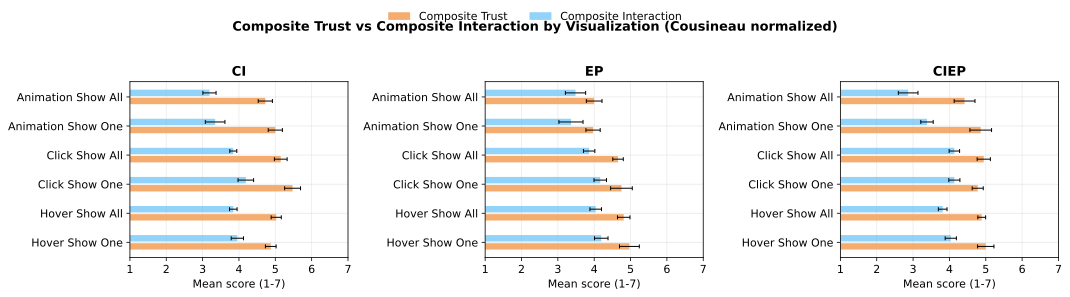

Combined (CI+EP+CIEP) Cousineau-normalized composite means with Morey-corrected SE by interaction condition


,interaction_group,trust_n,trust_mean,trust_se,trust_morey_factor,interaction_n,interaction_mean,interaction_se,interaction_morey_factor
0,Hover Show One,27,4.944,0.129,1.095,27,4.053,0.095,1.095
1,Hover Show All,27,4.917,0.082,1.095,27,3.893,0.070,1.095
2,Click Show One,27,5.028,0.132,1.095,27,4.165,0.104,1.095
3,Click Show All,27,4.935,0.095,1.095,27,3.947,0.081,1.095
4,Animation Show One,27,4.648,0.142,1.095,27,3.362,0.146,1.095
5,Animation Show All,27,4.407,0.132,1.095,27,3.169,0.141,1.095


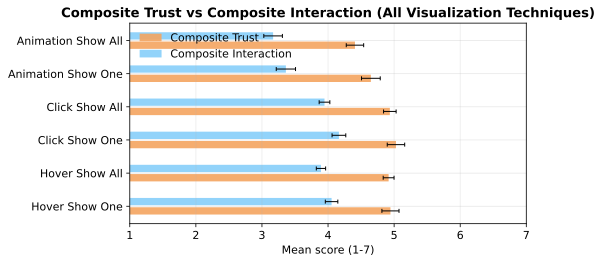

In [14]:
# 8.1 Three subplots (CI, EP, CIEP) with all 6 interaction conditions in each panel.
# Bars use Cousineau-normalized composite scores with Morey-corrected SE error bars.

if "composite_source" not in globals():
    composite_source = compute_composite_scores(trust_survey_expanded)

ROW_ORDER = TREATMENT_TECHNIQUE_ORDER
VIS_COLUMN_SPECS = [
    ("CI", "PI"),
    ("EP", "Ensemble"),
    ("CIEP", "PI + Ensemble"),
]


def summarize_cousineau_morey(
    data,
    value_col,
    participant_col="participant_id",
    condition_col="interaction_group",
    between_cols=None,
    k_conditions=None,
):
    between_cols = [] if between_cols is None else list(between_cols)
    required_cols = between_cols + [participant_col, condition_col, value_col]
    if any(col not in data.columns for col in required_cols):
        return pd.DataFrame(columns=between_cols + [condition_col, "n", "mean_score", "sd_score", "se_score", "k_conditions", "morey_factor"])

    working = data[required_cols].copy()
    working[value_col] = pd.to_numeric(working[value_col], errors="coerce")
    working = working.dropna(subset=[participant_col, condition_col, value_col])

    if working.empty:
        return pd.DataFrame(columns=between_cols + [condition_col, "n", "mean_score", "sd_score", "se_score", "k_conditions", "morey_factor"])

    if k_conditions is None:
        k_conditions = int(working[condition_col].nunique())

    participant_keys = between_cols + [participant_col]
    participant_condition_counts = (
        working.groupby(participant_keys, dropna=False)[condition_col]
        .nunique()
        .reset_index(name="_k_participant")
    )
    complete_participants = participant_condition_counts[
        participant_condition_counts["_k_participant"] >= k_conditions
    ][participant_keys]

    working = working.merge(complete_participants, on=participant_keys, how="inner")
    if working.empty:
        return pd.DataFrame(columns=between_cols + [condition_col, "n", "mean_score", "sd_score", "se_score", "k_conditions", "morey_factor"])

    participant_means = (
        working.groupby(participant_keys, dropna=False)[value_col]
        .mean()
        .reset_index(name="_participant_mean")
    )
    working = working.merge(participant_means, on=participant_keys, how="left")

    if between_cols:
        grand_means = (
            working.groupby(between_cols, dropna=False)[value_col]
            .mean()
            .reset_index(name="_grand_mean")
        )
        working = working.merge(grand_means, on=between_cols, how="left")
    else:
        working["_grand_mean"] = working[value_col].mean()

    working["_normalized_value"] = (
        working[value_col] - working["_participant_mean"] + working["_grand_mean"]
    )

    summary = (
        working.groupby(between_cols + [condition_col], dropna=False)["_normalized_value"]
        .agg(n="count", mean_score="mean", sd_score="std")
        .reset_index()
    )

    if k_conditions > 1:
        morey_factor = np.sqrt(k_conditions / (k_conditions - 1))
        summary["morey_factor"] = morey_factor
        summary["sd_score"] = summary["sd_score"] * morey_factor
    else:
        summary["morey_factor"] = np.nan

    summary["k_conditions"] = k_conditions
    summary["se_score"] = summary["sd_score"] / np.sqrt(summary["n"].clip(lower=1))
    return summary


raw_composite_treatment = composite_source[
    composite_source["condition_number"].isin(TREATMENT_CONDITION_NUMBERS)
].copy()

panel_input = raw_composite_treatment[
    raw_composite_treatment["interaction_group"].isin(ROW_ORDER)
    & raw_composite_treatment["visualization_group"].isin([label for _, label in VIS_COLUMN_SPECS])
].copy()

trust_panel_summary = summarize_cousineau_morey(
    panel_input,
    value_col="composite_trust_score",
    participant_col="participant_id",
    condition_col="interaction_group",
    between_cols=["visualization_group"],
    k_conditions=len(ROW_ORDER),
).rename(
    columns={
        "n": "trust_n",
        "mean_score": "trust_mean",
        "sd_score": "trust_sd",
        "se_score": "trust_se",
        "k_conditions": "trust_k",
        "morey_factor": "trust_morey_factor",
    }
)

interaction_panel_summary = summarize_cousineau_morey(
    panel_input,
    value_col="composite_interaction_score",
    participant_col="participant_id",
    condition_col="interaction_group",
    between_cols=["visualization_group"],
    k_conditions=len(ROW_ORDER),
).rename(
    columns={
        "n": "interaction_n",
        "mean_score": "interaction_mean",
        "sd_score": "interaction_sd",
        "se_score": "interaction_se",
        "k_conditions": "interaction_k",
        "morey_factor": "interaction_morey_factor",
    }
)

raw_summary = trust_panel_summary.merge(
    interaction_panel_summary,
    on=["visualization_group", "interaction_group"],
    how="outer",
)

# Keep all interaction x visualization cells so subplot axes stay aligned.
full_index = pd.MultiIndex.from_product(
    [ROW_ORDER, [label for _, label in VIS_COLUMN_SPECS]],
    names=["interaction_group", "visualization_group"],
)
raw_summary = (
    raw_summary.set_index(["interaction_group", "visualization_group"])
    .reindex(full_index)
    .reset_index()
)

print("Cousineau-normalized composite trust/interaction means with Morey-corrected SE by interaction x visualization")
display(
    raw_summary[
        [
            "interaction_group",
            "visualization_group",
            "trust_n",
            "trust_mean",
            "trust_se",
            "trust_morey_factor",
            "interaction_n",
            "interaction_mean",
            "interaction_se",
            "interaction_morey_factor",
        ]
    ].round(3)
)

fig, axes = plt.subplots(1, len(VIS_COLUMN_SPECS), figsize=(15, 3.8), sharey=True)
if len(VIS_COLUMN_SPECS) == 1:
    axes = [axes]

y = np.arange(len(ROW_ORDER))
bar_height = 0.22
bar_offset = 0.14

for ax, (vis_token, vis_label) in zip(axes, VIS_COLUMN_SPECS):
    panel = raw_summary[raw_summary["visualization_group"] == vis_label].copy()
    panel["interaction_group"] = pd.Categorical(panel["interaction_group"], categories=ROW_ORDER, ordered=True)
    panel = panel.sort_values("interaction_group").reset_index(drop=True)

    trust_mean = pd.to_numeric(panel["trust_mean"], errors="coerce").to_numpy()
    trust_se = pd.to_numeric(panel["trust_se"], errors="coerce").to_numpy()
    interaction_mean = pd.to_numeric(panel["interaction_mean"], errors="coerce").to_numpy()
    interaction_se = pd.to_numeric(panel["interaction_se"], errors="coerce").to_numpy()

    trust_width = np.clip(trust_mean - 1.0, 0.0, None)
    interaction_width = np.clip(interaction_mean - 1.0, 0.0, None)

    ax.barh(
        y - bar_offset,
        trust_width,
        left=1.0,
        height=bar_height,
        color="#F4A460",
        alpha=0.9,
        label="Composite Trust",
    )
    ax.barh(
        y + bar_offset,
        interaction_width,
        left=1.0,
        height=bar_height,
        color="#87CEFA",
        alpha=0.9,
        label="Composite Interaction",
    )

    trust_mask = np.isfinite(trust_mean)
    if trust_mask.any():
        ax.errorbar(
            trust_mean[trust_mask],
            (y - bar_offset)[trust_mask],
            xerr=trust_se[trust_mask],
            fmt="none",
            ecolor="black",
            capsize=2,
            linewidth=1,
        )

    interaction_mask = np.isfinite(interaction_mean)
    if interaction_mask.any():
        ax.errorbar(
            interaction_mean[interaction_mask],
            (y + bar_offset)[interaction_mask],
            xerr=interaction_se[interaction_mask],
            fmt="none",
            ecolor="black",
            capsize=2,
            linewidth=1,
        )

    ax.set_title(vis_token, fontweight="bold")
    ax.set_yticks(y)
    ax.set_yticklabels(ROW_ORDER, rotation=0)
    ax.tick_params(axis="y", labelleft=True)
    ax.set_xlim(1, 7)
    ax.set_xticks(np.arange(1, 8, 1))
    ax.set_xlabel("Mean score (1-7)")
    ax.grid(True, axis="x", alpha=0.25)

fig.suptitle(
    "Composite Trust vs Composite Interaction by Visualization (Cousineau normalized)",
    fontsize=13,
    fontweight="bold",
    y=1.03,
)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False, bbox_to_anchor=(0.5, 1.10))
plt.tight_layout()
plt.show()

# 8.2 Combined across all visualization techniques (CI + EP + CIEP)
combined_input = raw_composite_treatment[
    raw_composite_treatment["interaction_group"].isin(ROW_ORDER)
].copy()

combined_trust_summary = summarize_cousineau_morey(
    combined_input,
    value_col="composite_trust_score",
    participant_col="participant_id",
    condition_col="interaction_group",
    between_cols=None,
    k_conditions=len(ROW_ORDER),
).rename(
    columns={
        "n": "trust_n",
        "mean_score": "trust_mean",
        "sd_score": "trust_sd",
        "se_score": "trust_se",
        "k_conditions": "trust_k",
        "morey_factor": "trust_morey_factor",
    }
)

combined_interaction_summary = summarize_cousineau_morey(
    combined_input,
    value_col="composite_interaction_score",
    participant_col="participant_id",
    condition_col="interaction_group",
    between_cols=None,
    k_conditions=len(ROW_ORDER),
).rename(
    columns={
        "n": "interaction_n",
        "mean_score": "interaction_mean",
        "sd_score": "interaction_sd",
        "se_score": "interaction_se",
        "k_conditions": "interaction_k",
        "morey_factor": "interaction_morey_factor",
    }
)

combined_interaction_summary = combined_trust_summary.merge(
    combined_interaction_summary,
    on=["interaction_group"],
    how="outer",
)
combined_interaction_summary["interaction_group"] = pd.Categorical(
    combined_interaction_summary["interaction_group"],
    categories=ROW_ORDER,
    ordered=True,
)
combined_interaction_summary = combined_interaction_summary.sort_values("interaction_group").reset_index(drop=True)

print("Combined (CI+EP+CIEP) Cousineau-normalized composite means with Morey-corrected SE by interaction condition")
display(
    combined_interaction_summary[
        [
            "interaction_group",
            "trust_n",
            "trust_mean",
            "trust_se",
            "trust_morey_factor",
            "interaction_n",
            "interaction_mean",
            "interaction_se",
            "interaction_morey_factor",
        ]
    ].round(3)
)

fig, ax = plt.subplots(figsize=(7.6, 3.8))

y = np.arange(len(ROW_ORDER))
bar_height = 0.22
bar_offset = 0.14

trust_mean = pd.to_numeric(combined_interaction_summary["trust_mean"], errors="coerce").to_numpy()
trust_se = pd.to_numeric(combined_interaction_summary["trust_se"], errors="coerce").to_numpy()
interaction_mean = pd.to_numeric(combined_interaction_summary["interaction_mean"], errors="coerce").to_numpy()
interaction_se = pd.to_numeric(combined_interaction_summary["interaction_se"], errors="coerce").to_numpy()

trust_width = np.clip(trust_mean - 1.0, 0.0, None)
interaction_width = np.clip(interaction_mean - 1.0, 0.0, None)

ax.barh(
    y - bar_offset,
    trust_width,
    left=1.0,
    height=bar_height,
    color="#F4A460",
    alpha=0.9,
    label="Composite Trust",
)
ax.barh(
    y + bar_offset,
    interaction_width,
    left=1.0,
    height=bar_height,
    color="#87CEFA",
    alpha=0.9,
    label="Composite Interaction",
)

trust_mask = np.isfinite(trust_mean)
if trust_mask.any():
    ax.errorbar(
        trust_mean[trust_mask],
        (y - bar_offset)[trust_mask],
        xerr=trust_se[trust_mask],
        fmt="none",
        ecolor="black",
        capsize=2,
        linewidth=1,
    )

interaction_mask = np.isfinite(interaction_mean)
if interaction_mask.any():
    ax.errorbar(
        interaction_mean[interaction_mask],
        (y + bar_offset)[interaction_mask],
        xerr=interaction_se[interaction_mask],
        fmt="none",
        ecolor="black",
        capsize=2,
        linewidth=1,
    )

ax.set_yticks(y)
ax.set_yticklabels(ROW_ORDER, rotation=0)
ax.set_xlim(1, 7)
ax.set_xticks(np.arange(1, 8, 1))
ax.set_xlabel("Mean score (1-7)")
ax.set_title("Composite Trust vs Composite Interaction (All Visualization Techniques)", fontweight="bold")
ax.grid(True, axis="x", alpha=0.25)
ax.legend(frameon=False, loc="upper left")

plt.tight_layout()
plt.show()
